# Modeling — Stacking Ensemble with Optuna + SHAP

---
**Goal:** Reproduce the production model interactively.

Pipeline (mirrors `src/train_stacking.py`):
1. Load + engineer + SMOTE + scale via `run_pipeline`
2. **Feature selection**: mutual information + correlation filter
3. **Optuna** tunes RF, XGBoost, LightGBM (5-fold ROC-AUC)
4. **StackingClassifier**: RF + XGB + LGBM → LogisticRegression meta-learner
5. Evaluate on held-out test (F1, ROC-AUC, PR-AUC, ROC + PR curves, confusion matrix)
6. **SHAP** summary plot
7. Compare against a single-model baseline (XGBoost) to show the stacking lift

> ⚠️ This notebook uses a **reduced** Optuna budget (8 trials/model) to keep the runtime around 5–10 min. The production script uses **30 trials/model** and runs ~30–60 min.

## 1. Imports

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import shap
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

from src.preprocessing import run_pipeline

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
N_TRIALS     = 8       # production: 30
CV_FOLDS     = 5
print('Imports OK')

C:\Users\bulat\PycharmProjects\MLFinalProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2. Load Preprocessed Data

One call gives us SMOTE'd, scaled, 17-feature train/test.

In [2]:
X_train, X_test, y_train, y_test, scaler = run_pipeline(
    filepath=str(PROJECT_ROOT / 'data' / 'magic04.data'),
    apply_smote=True,
)
print(f'\nX_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train balance: {y_train.value_counts().to_dict()}')
print(f'y_test  balance: {y_test.value_counts().to_dict()}')

  MAGIC Telescope — Preprocessing Pipeline (engineered + SMOTE)
Data loaded: 19020 rows, 11 columns
Labels encoded: Gamma (1) = 12332, Hadron (0) = 6688
Dropped 98 raw rows violating physical constraints
Train: (15137, 17), Test: (3785, 17)
SMOTE: 15137 -> 19606 (synthetic=4469, dropped=0 = 0.0%)
Scaled 17 features (mean=0, std=1)

Pipeline complete.

X_train: (19606, 17), X_test: (3785, 17)
y_train balance: {0: 9803, 1: 9803}
y_test  balance: {1: 2451, 0: 1334}


## 3. Feature Selection

Two-step process:
1. **Mutual information** — drop the bottom 10% of features by `mutual_info_classif`.
2. **Correlation filter** — for any pair with `|r| > 0.95`, drop the one with the lower MI score.

Goal: remove noise and redundancy before the (expensive) Optuna tuning.

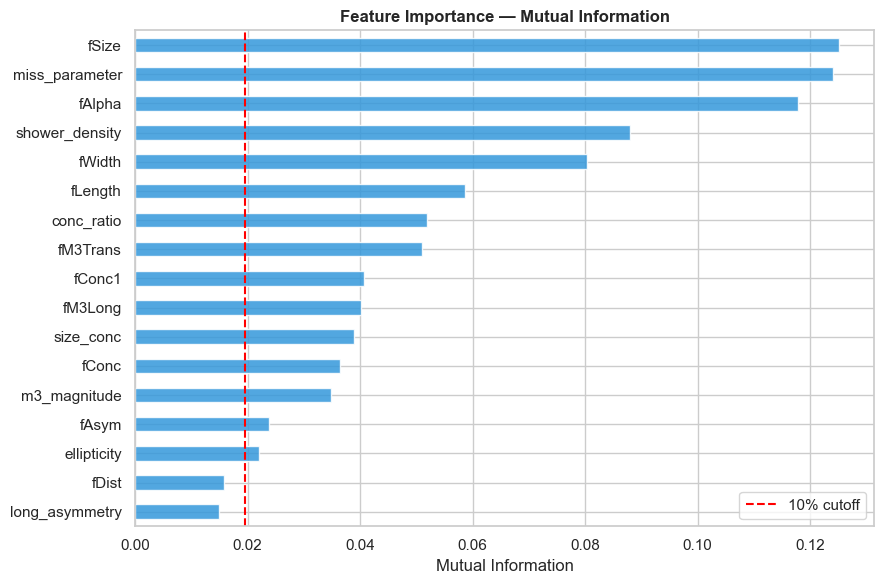

In [3]:
mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
mi_series.plot.barh(ax=ax, color='#3498db', alpha=0.85)
ax.axvline(x=mi_series.quantile(0.10), color='red', linestyle='--', label='10% cutoff')
ax.set_xlabel('Mutual Information')
ax.set_title('Feature Importance — Mutual Information', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
mi_cutoff = mi_series.quantile(0.10)
kept = mi_series[mi_series > mi_cutoff].sort_values(ascending=False)
print(f'After MI filter: {len(kept)} / {X_train.shape[1]} features remain')

# Correlation filter
cols = list(kept.index)
corr = X_train[cols].corr().abs()
to_drop = set()
for i, c1 in enumerate(cols):
    if c1 in to_drop:
        continue
    for c2 in cols[i + 1:]:
        if c2 in to_drop:
            continue
        if corr.loc[c1, c2] > 0.95:
            drop_target = c2 if kept[c1] >= kept[c2] else c1
            to_drop.add(drop_target)

selected = [c for c in cols if c not in to_drop]
print(f'After correlation filter: {len(selected)} features')
print(f'Selected: {selected}')
print(f'Dropped:  {sorted(set(X_train.columns) - set(selected))}')

X_train = X_train[selected]
X_test  = X_test[selected]

After MI filter: 15 / 17 features remain
After correlation filter: 12 features
Selected: ['fSize', 'miss_parameter', 'fAlpha', 'shower_density', 'fWidth', 'fLength', 'conc_ratio', 'fM3Trans', 'fConc1', 'fM3Long', 'm3_magnitude', 'fAsym']
Dropped:  ['ellipticity', 'fConc', 'fDist', 'long_asymmetry', 'size_conc']


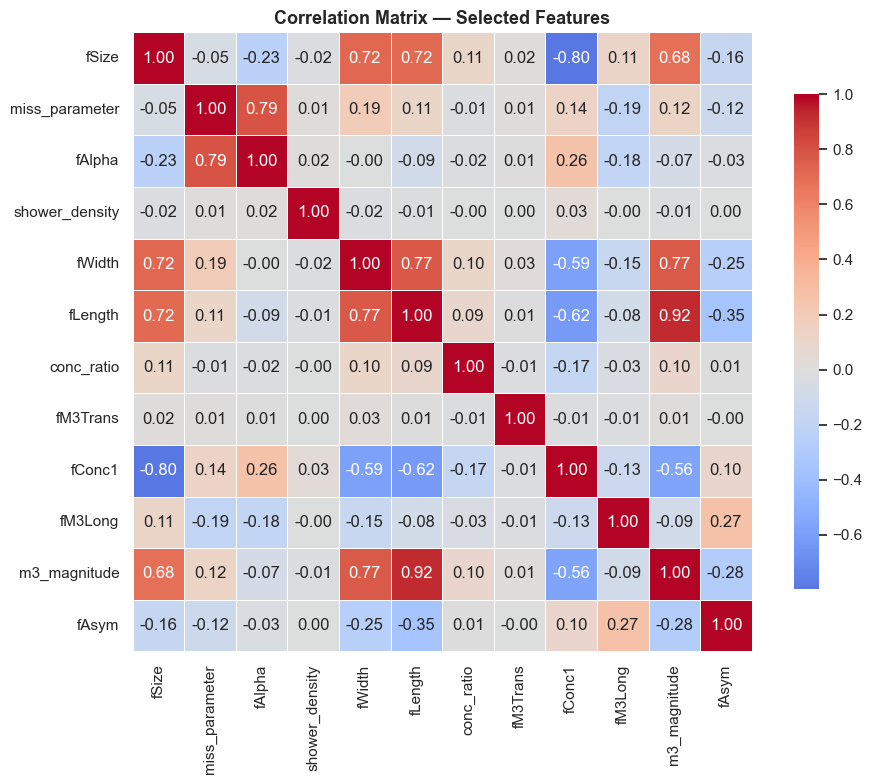

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Optuna Hyperparameter Tuning

Each base learner is tuned independently. Objective = mean ROC-AUC over a 5-fold `StratifiedKFold`.
Sampler = `TPESampler` (Bayesian, beats random search after the first few trials).

In [6]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def cv_auc(model, X, y):
    return float(cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean())

def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        max_depth=trial.suggest_int('max_depth', 6, 30),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    return cv_auc(RandomForestClassifier(**params), X_train, y_train)

def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 3, 12),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        gamma=trial.suggest_float('gamma', 0.0, 5.0),
        random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0, n_jobs=-1,
    )
    return cv_auc(XGBClassifier(**params), X_train, y_train)

def objective_lgbm(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', -1, 15),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1,
    )
    return cv_auc(LGBMClassifier(**params), X_train, y_train)

def tune(name, objective):
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    print(f'  {name}: best ROC-AUC = {study.best_value:.4f}')
    return study

print(f'Tuning each base learner with {N_TRIALS} trials, {CV_FOLDS}-fold CV…')
print('\n[1/3] Random Forest')
study_rf   = tune('RF',   objective_rf)
print('\n[2/3] XGBoost')
study_xgb  = tune('XGB',  objective_xgb)
print('\n[3/3] LightGBM')
study_lgbm = tune('LGBM', objective_lgbm)

Tuning each base learner with 8 trials, 5-fold CV…

[1/3] Random Forest
  RF: best ROC-AUC = 0.9404

[2/3] XGBoost
  XGB: best ROC-AUC = 0.9581

[3/3] LightGBM
  LGBM: best ROC-AUC = 0.9588


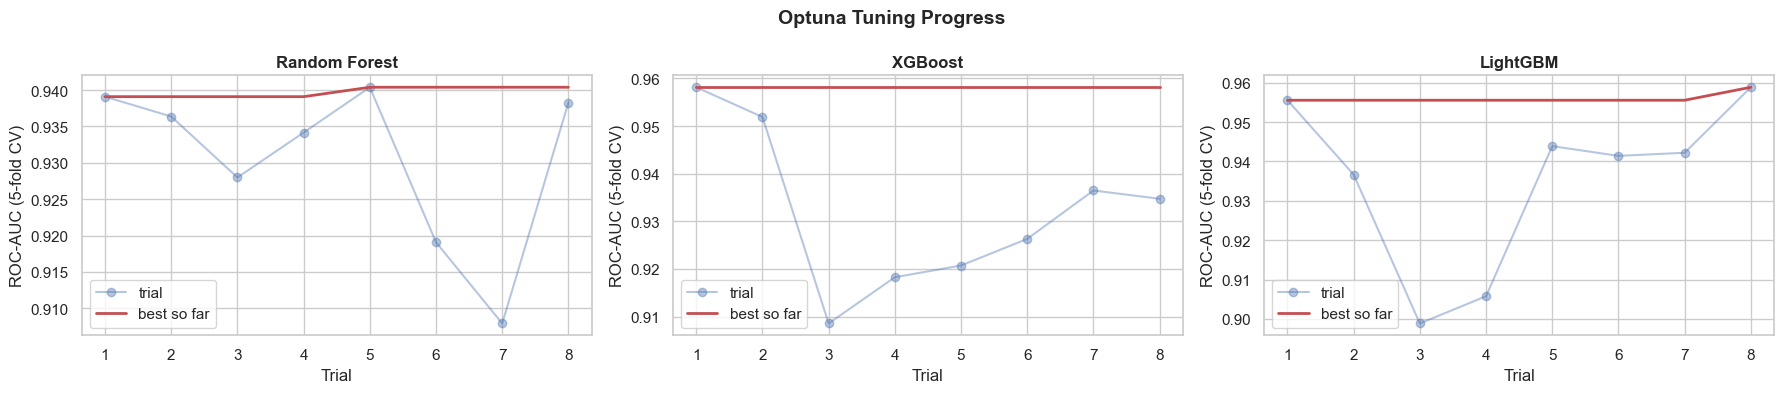

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (study, name) in zip(axes, [(study_rf, 'Random Forest'),
                                     (study_xgb, 'XGBoost'),
                                     (study_lgbm, 'LightGBM')]):
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    ax.plot(range(1, len(values) + 1), values, 'o-', alpha=0.4, label='trial')
    ax.plot(range(1, len(values) + 1), best_so_far, 'r-', linewidth=2, label='best so far')
    ax.set_xlabel('Trial')
    ax.set_ylabel('ROC-AUC (5-fold CV)')
    ax.set_title(name, fontweight='bold')
    ax.legend()

plt.suptitle('Optuna Tuning Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
print('Best params:\n')
print('RF  :', study_rf.best_params)
print('XGB :', study_xgb.best_params)
print('LGBM:', study_lgbm.best_params)

Best params:

RF  : {'n_estimators': 237, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt'}
XGB : {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973}
LGBM: {'n_estimators': 174, 'max_depth': 15, 'num_leaves': 102, 'learning_rate': 0.24420460844911424, 'min_child_samples': 46, 'subsample': 0.8391599915244341, 'colsample_bytree': 0.9687496940092467}


## 5. Build the Stacking Ensemble

```
                  ┌── RandomForestClassifier (proba) ──┐
X (selected) ───▶ ├── XGBClassifier         (proba) ──┼─▶ LogisticRegression ─▶ ŷ
                  └── LGBMClassifier        (proba) ──┘
```

`cv=5` means each base learner emits **out-of-fold** probabilities for the meta-learner — this prevents the meta-learner from overfitting on the base learners' training-set predictions.

`passthrough=False`: the meta-learner sees only the three probability columns, not the raw 12 features.

In [9]:
rf   = RandomForestClassifier(**study_rf.best_params,   random_state=RANDOM_STATE, n_jobs=-1)
xgb  = XGBClassifier(**study_xgb.best_params,           random_state=RANDOM_STATE,
                     eval_metric='logloss', verbosity=0, n_jobs=-1)
lgbm = LGBMClassifier(**study_lgbm.best_params,         random_state=RANDOM_STATE,
                      verbosity=-1, n_jobs=-1)

stack = StackingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=CV_FOLDS,
    passthrough=False,
    n_jobs=-1,
)

print('Fitting stacking classifier…')
stack.fit(X_train, y_train)
print('Done.')

Fitting stacking classifier…
Done.


## 6. Evaluate on Held-out Test Set

In [10]:
y_pred  = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:, 1]

metrics = {
    'F1':       f1_score(y_test, y_pred),
    'ROC-AUC':  roc_auc_score(y_test, y_proba),
    'PR-AUC':   average_precision_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f'  {k:8s} = {v:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Hadron (0)', 'Gamma (1)']))

  F1       = 0.9054
  ROC-AUC  = 0.9420
  PR-AUC   = 0.9628

Classification report:
              precision    recall  f1-score   support

  Hadron (0)       0.82      0.84      0.83      1334
   Gamma (1)       0.91      0.90      0.91      2451

    accuracy                           0.88      3785
   macro avg       0.87      0.87      0.87      3785
weighted avg       0.88      0.88      0.88      3785



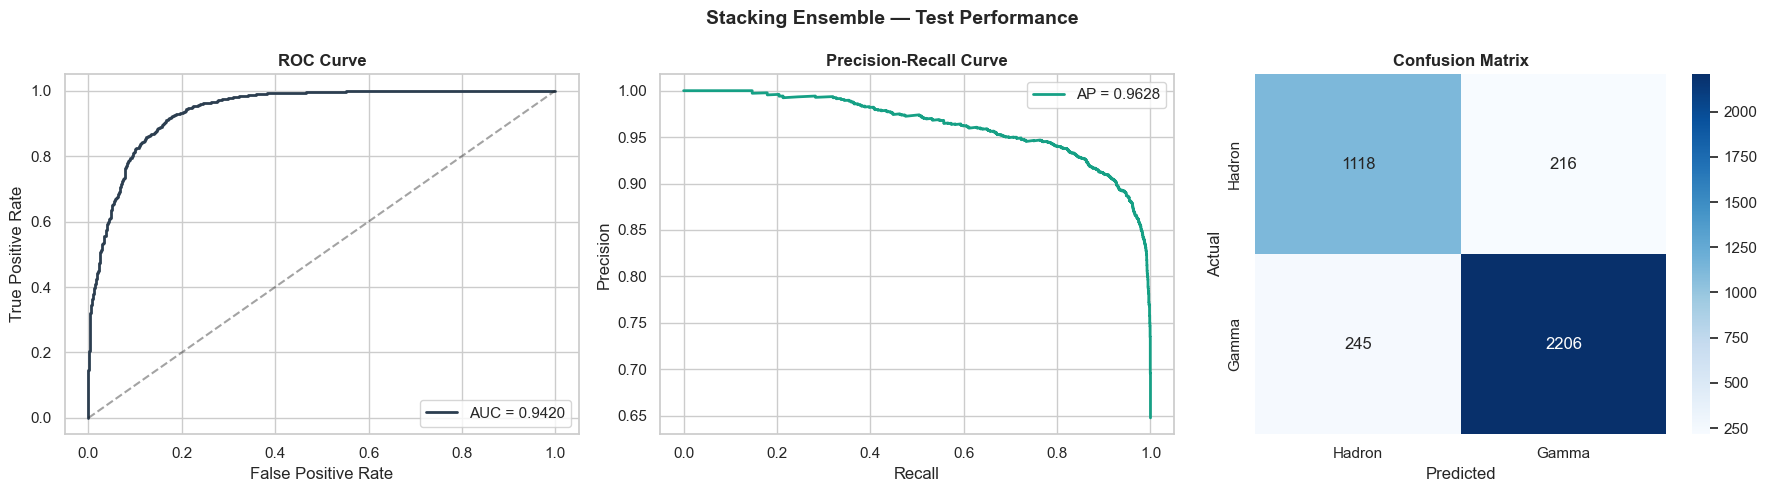

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#2c3e50', linewidth=2, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color='#16a085', linewidth=2, label=f'AP = {metrics["PR-AUC"]:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hadron', 'Gamma'],
            yticklabels=['Hadron', 'Gamma'], ax=axes[2])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('Stacking Ensemble — Test Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. SHAP — Why does the model predict what it predicts?

SHAP values explain each base learner; we use the Random Forest base learner here because `TreeExplainer` is fast on it (StackingClassifier itself is not a tree model).

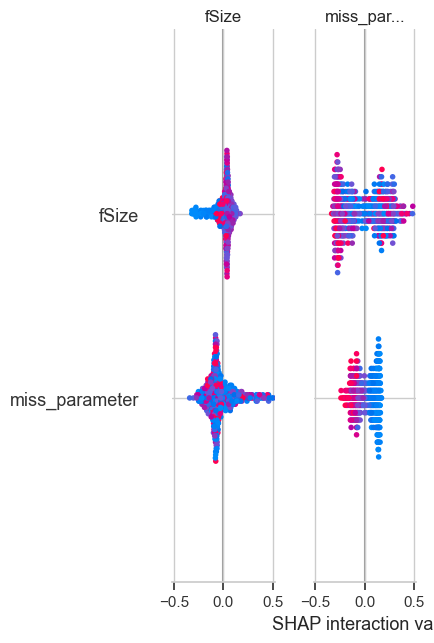

In [12]:
rf_base = stack.named_estimators_['rf']
explainer = shap.TreeExplainer(rf_base)
sample = X_train.sample(min(500, len(X_train)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # gamma class

shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()

## 8. Comparison Against a Baseline

Is stacking actually worth the complexity? Compare to a single tuned XGBoost (the strongest single model from the original 4-model baseline).

In [13]:
xgb_solo = XGBClassifier(**study_xgb.best_params, random_state=RANDOM_STATE,
                         eval_metric='logloss', verbosity=0, n_jobs=-1)
xgb_solo.fit(X_train, y_train)
xgb_proba = xgb_solo.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_solo.predict(X_test)

comparison = pd.DataFrame([
    {
        'Model': 'XGBoost (tuned solo)',
        'F1':       f1_score(y_test, xgb_pred),
        'ROC-AUC':  roc_auc_score(y_test, xgb_proba),
        'PR-AUC':   average_precision_score(y_test, xgb_proba),
    },
    {
        'Model': 'Stacking (RF + XGB + LGBM → LR)',
        'F1':       metrics['F1'],
        'ROC-AUC':  metrics['ROC-AUC'],
        'PR-AUC':   metrics['PR-AUC'],
    },
]).set_index('Model').round(4)
comparison

,F1,ROC-AUC,PR-AUC
Model,,,
XGBoost (tuned solo),0.9053,0.9389,0.9598
Stacking (RF + XGB + LGBM → LR),0.9054,0.9420,0.9628


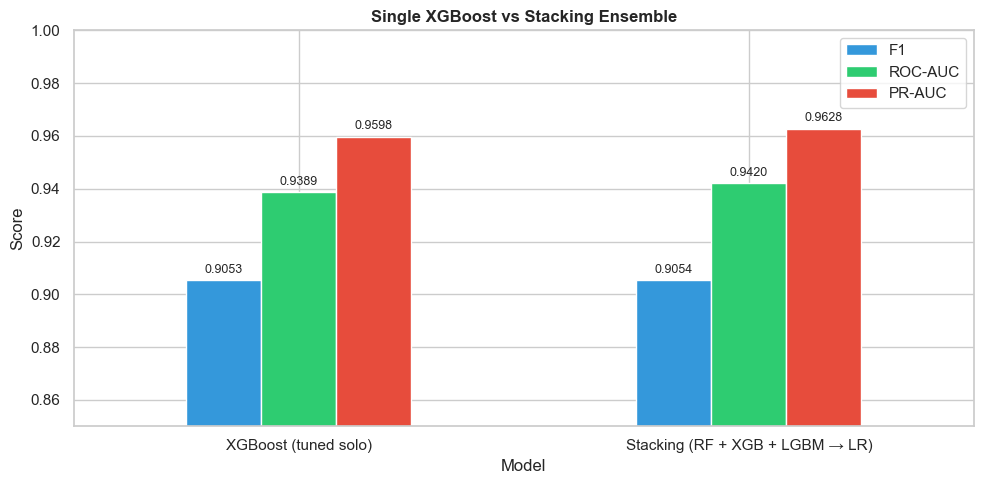

In [14]:
ax = comparison.plot.bar(figsize=(10, 5), color=['#3498db', '#2ecc71', '#e74c3c'], rot=0)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('Single XGBoost vs Stacking Ensemble', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 9. Summary

**What we built:**
- A 3-learner stacking ensemble (RF + XGBoost + LightGBM) with a LogisticRegression meta-learner.
- Hyperparameters chosen by Optuna's TPE sampler over 5-fold ROC-AUC.
- Feature set reduced from 17 → ~12 via mutual information + correlation filter.

**Why it works:**
- Tree-based base learners catch non-linear interactions; the LR meta-learner finds the best linear combination of their probabilities.
- 5-fold internal CV inside `StackingClassifier` prevents the meta-learner from overfitting on training-set predictions.

**For production:** run `python src/train_stacking.py` from the project root — same pipeline but with 30 trials per learner, MLflow logging, SHAP artifact, and persistence of `models/stacking_model.pkl`, `scaler.pkl`, `selected_features.json`, `baseline_stats.json` (used by the API for PSI drift detection).